# Rilassamento SDP per discriminazione di \(n_x\) stati con vincoli su componenti di Fock

Codice generalizzato per la discriminazione di stati nel caso di:

- $n_x$ preparazioni $\rho_x$, con $x=0,\dots,n_x-1$;
- $n_x$ esiti di misura $M_b$, con $b=0,\dots,n_x-1$;
- operatori di proiezione sugli stati di Fock $\sigma_n = |n\rangle\langle n|$, con $n=0,\dots,n_{\mathrm{trunc}}$ su cui si conosce un vincolo.

La Witness da ottimizzare è

$$
W_{n_x\mathrm{disc}} = \frac{1}{n_x}\sum_{x=0}^{n_x-1} \operatorname{Tr}(\rho_x M_x)
$$

E si sa che:

$$
\operatorname{Tr}(\rho_x \sigma_n) \ge 1 - \omega_{x,n}
$$

In [1]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt
import math

## Riduzione e canonizzazione delle parole

Gli operatori usati sono rappresentati da stringhe:

- `r0`, `r1`, ... per gli stati $\rho_x$;
- `M0`, `M1`, ... per le POVMs $M_b$;
- `s0`, `s1`, ... per i proiettori fotonici $\sigma_n$.

Per la riduzione delle parole si possono usare le relazioni proiettive:

$$
M_bM_{b'}=\delta_{bb'}M_b
$$

$$
\sigma_n\sigma_m=\delta_{nm}\sigma_n
$$

La ciclicità della traccia viene gestita scegliendo una forma canonica tra tutte le rotazioni cicliche della parola e della parola invertita (tutti gli operatori sono Hermitiani).

In [ ]:
def reduce_word(w):
    """
    Riduce una parola usando le relazioni di idempotenza dei proiettori.
    Non elimina qui i prodotti ortogonali M_b M_b' = 0 o sigma_n sigma_m = 0
    per b != b' o n != m. Quelli sono gestiti da is_zero_word().
    """
    w = list(w)
    changed = True

    while changed:
        changed = False
        out = []
        i = 0
        while i < len(w):
            if i + 1 < len(w):
                a, b = w[i], w[i + 1]

                # M_b M_b = M_b
                if a == b and a.startswith("M"):
                    out.append(a)
                    i += 2
                    changed = True
                    continue
                # sigma_n sigma_n = sigma_n
                if a == b and a.startswith("s"):
                    out.append(a)
                    i += 2
                    changed = True
                    continue
            out.append(w[i])
            i += 1
        w = out

    return tuple(w)


def is_zero_word(w):
    """
    Riconosce parole che valgono zero per ortogonalità:
    M_b M_b' = 0 se b != b'
    sigma_n sigma_m = 0 se n != m
    """
    for a, b in zip(w, w[1:]):

        # M_b M_b' = 0 per b != b'
        if a.startswith("M") and b.startswith("M") and a != b:
            return True
        # sigma_n sigma_m = 0 per n != m
        if a.startswith("s") and b.startswith("s") and a != b:
            return True

    return False


def rotations(w):
    """Restituisce tutte le rotazioni cicliche della parola w."""
    w = tuple(w)
    if len(w) == 0:
        return [()]
    return [w[i:] + w[:i] for i in range(len(w))]


def canonical_trace_word(w):
    """
    Forma canonica di una parola dentro una traccia.
    Usa ciclicità della traccia e inversione, assumendo operatori hermitiani.
    """
    w = reduce_word(tuple(w))
    candidates = rotations(w) + rotations(tuple(reversed(w)))
    candidates = [reduce_word(c) for c in candidates]
    return min(candidates)

### Test rapidi sulle parole

In [3]:
examples = [
    ("M0", "M0", "r0", "s0", "s0"),
    ("M0", "M1"),
    ("s0", "s1"),
    ("r0", "M1", "s0"),
    ("s0", "r0", "M1"),
]

for word in examples:
    print(word)
    print("  reduced: ", reduce_word(word))
    print("  zero?   ", is_zero_word(word))
    print("  canon:  ", canonical_trace_word(word))

('M0', 'M0', 'r0', 's0', 's0')
  reduced:  ('M0', 'r0', 's0')
  zero?    False
  canon:   ('M0', 'r0', 's0')
('M0', 'M1')
  reduced:  ('M0', 'M1')
  zero?    True
  canon:   ('M0', 'M1')
('s0', 's1')
  reduced:  ('s0', 's1')
  zero?    True
  canon:   ('s0', 's1')
('r0', 'M1', 's0')
  reduced:  ('r0', 'M1', 's0')
  zero?    False
  canon:   ('M1', 'r0', 's0')
('s0', 'r0', 'M1')
  reduced:  ('s0', 'r0', 'M1')
  zero?    False
  canon:   ('M1', 'r0', 's0')


## Classe per il rilassamento SDP tracciale

La variabile `T(w)` rappresenta simbolicamente l'operazione di traccia.

La matrice dei momenti è

$$
\Gamma_{u,v}=\mathrm{Tr}(u^\dagger v).
$$

Per ogni stato misto $\rho_x$, imponiamo anche la localizing matrix $\gamma_x$ associata al vincolo:

$$
\rho_x - \rho_x^2 \succeq 0.
$$

In [4]:
class TracialSDP:
    def __init__(self):
        self.vars = {}

    def T(self, w):
        """Restituisce la variabile CVXPY associata a Tr(w), oppure 0 se la parola è nulla."""
        w = tuple(w)

        if is_zero_word(w):
            return 0

        key = canonical_trace_word(w)
        if is_zero_word(key):
            return 0

        if key not in self.vars:
            name = "T_I" if len(key) == 0 else "T_" + "_".join(key)
            self.vars[key] = cp.Variable(name=name)

        return self.vars[key]

    def moment_matrix(self, words):
        """Costruisce Gamma con Gamma[u,v] = Tr(u^dagger v)."""
        n = len(words)
        G = [[None for _ in range(n)] for _ in range(n)]

        for i, u in enumerate(words):
            for j, v in enumerate(words):
                u_dagger = tuple(reversed(u))
                G[i][j] = self.T(u_dagger + tuple(v))

        return cp.bmat(G)

    def localizing_matrix(self, words, rho):
        """
        Costruisce la localizing matrix associata a rho - rho^2 >= 0.s
        Elemento [u,v] = Tr(u^dagger (rho-rho^2) v).
        """
        n = len(words)
        L = [[None for _ in range(n)] for _ in range(n)]

        for i, u in enumerate(words):
            for j, v in enumerate(words):
                left = tuple(reversed(u))
                right = tuple(v)
                L[i][j] = self.T(left + (rho,) + right) - self.T(left + (rho, rho) + right)

        return cp.bmat(L)

## Costruzione automatica delle liste di operatori e parole

Le funzioni seguenti costruiscono una lista di parole in maniera abbastanza ordinata in modo che gli unici input siano il numero di diversi stati considerati e il numero di distinte componenti di Fock sottoposte a constraints.

In [5]:
def build_operators(n_x, n_trunc):
    rhos = [f"r{x}" for x in range(n_x)]
    measurements = [f"M{b}" for b in range(n_x)]
    sigmas = [f"s{n}" for n in range(n_trunc + 1)]
    return rhos, measurements, sigmas


def build_words(n_x, n_trunc, include_extra=True):
    rhos, measurements, sigmas = build_operators(n_x, n_trunc)

    words = [()]

    # Parole di lunghezza 1
    words += [(r,) for r in rhos]
    words += [(M,) for M in measurements]
    words += [(s,) for s in sigmas]

    # Parole di lunghezza 2 rilevanti
    words += [(r, M) for r in rhos for M in measurements]
    words += [(r, s) for r in rhos for s in sigmas]
    words += [(s, M) for s in sigmas for M in measurements]
    words += [(r, r) for r in rhos]
    words += [(s, r) for s in sigmas for r in rhos]
    
    if include_extra:
        # Alcune parole più forti (da usare per n_x > 2)
        words += [(r, M, s) for r in rhos for M in measurements for s in sigmas]
        words += [(M, r, s) for M in measurements for r in rhos for s in sigmas]

    # Applica le regole di proiezione riducendo le parole
    unique = []
    seen = set()
    for w in words:
        w = reduce_word(tuple(w))

        if is_zero_word(w):
            continue

        if w not in seen:
            seen.add(w)
            unique.append(w)

    return unique


def build_localizing_words(n_x, n_trunc):
    rhos, measurements, sigmas = build_operators(n_x, n_trunc)

    words = [()]
    words += [(r,) for r in rhos]
    words += [(M,) for M in measurements]
    words += [(s,) for s in sigmas]

    return words

## Solver generale per discriminazione di \(n_x\) stati

L'input `omega` può essere:

- uno scalare: stesso vincolo per ogni \(x,n\);
- un array di forma `(n_x, n_trunc+1)`.

Il vincolo implementato è:

$$
\mathrm{Tr}(\rho_x \sigma_n) \ge 1 - \omega_{x,n}.
$$

In [ ]:
def prepare_omega(omega, n_x, n_trunc):
    if np.isscalar(omega):
        return np.full((n_x, n_trunc + 1), float(omega))

    omega = np.asarray(omega, dtype=float)
    return omega

def solve_n_state_discrimination(n_x, n_trunc, omega, solver="CLARABEL", verbose=False, include_extra_words=True):
    """
    Risolve un rilassamento SDP per discriminazione di n_x stati
    con vincoli sulle componenti fotoniche fino a n_trunc.
    """
    omega = prepare_omega(omega, n_x, n_trunc)

    sdp = TracialSDP()
    rhos, measurements, sigmas = build_operators(n_x, n_trunc)

    words = build_words(n_x, n_trunc, include_extra=include_extra_words)
    loc_words = build_localizing_words(n_x, n_trunc)

    Gamma = sdp.moment_matrix(words)
    constraints = [Gamma >> 0]

    # Localizing matrices: rho_x - rho_x^2 >= 0
    for r in rhos:
        constraints.append(sdp.localizing_matrix(loc_words, r) >> 0)

    # Normalizzazione degli stati: Tr(rho_x)=1
    for r in rhos:
        constraints.append(sdp.T((r,)) == 1)

    # Normalizzazione dei proiettori: Tr(sigma_n)=1
    for s in sigmas:
        constraints.append(sdp.T((s,)) == 1)

    # Vincoli fotonici: Tr(rho_x sigma_n) >= 1 - omega[x,n]
    for x, r in enumerate(rhos):
        for n, s in enumerate(sigmas):
            constraints.append(sdp.T((r, s)) >= 1 - omega[x, n])

    # Completezza della misura sul supporto degli stati:
    # sum_b Tr(rho_x M_b) = Tr(rho_x) = 1
    for r in rhos:
        constraints.append(sum(sdp.T((r, M)) for M in measurements) == 1)

    # Witness di n-state discrimination
    W = sum(sdp.T((rhos[x], measurements[x])) for x in range(n_x)) / n_x

    problem = cp.Problem(cp.Maximize(W), constraints)
    problem.solve(solver=solver, verbose=verbose)

    return {
        "n_x": n_x,
        "n_trunc": n_trunc,
        "omega": omega,
        "sdp_upper_bound": problem.value,
        "status": problem.status,
        "num_moment_variables": len(sdp.vars),
        "num_words": len(words),
        "words": words,
        "moment_variables": sdp.vars,
    }

## Check: caso \(n_x=2\), solo vincolo sul vuoto

Per $n_x=2$, $n_{\mathrm{trunc}}=0$, il risultato analitico atteso è

$$
W_{2\mathrm{disc}} = \frac12 + \sqrt{\omega(1-\omega)}.
$$

In [7]:
omegas = [0.01, 0.05, 0.10, 0.25, 0.50]
results_2 = []

for omega in omegas:
    res = solve_n_state_discrimination(
        n_x=2,
        n_trunc=0,
        omega=omega,
        solver="CLARABEL",
        include_extra_words=True,
    )
    analytic = 0.5 + np.sqrt(omega * (1 - omega))
    res["analytic"] = analytic
    res["absolute_error"] = None if res["sdp_upper_bound"] is None else abs(res["sdp_upper_bound"] - analytic)
    results_2.append(res)

for res in results_2:
    print(
        f"omega={res['omega'][0,0]:.3f} | "
        f"SDP={res['sdp_upper_bound']:.10f} | "
        f"analytic={res['analytic']:.10f} | "
        f"err={res['absolute_error']:.2e} | "
        f"status={res['status']} | "
        f"vars={res['num_moment_variables']}"
    )

/tmp/ipykernel_9825/1822338672.py:56: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=solver, verbose=verbose)


omega=0.010 | SDP=0.5994987347 | analytic=0.5994987437 | err=8.98e-09 | status=optimal_inaccurate | vars=136
omega=0.050 | SDP=0.7179448551 | analytic=0.7179449472 | err=9.21e-08 | status=optimal_inaccurate | vars=136
omega=0.100 | SDP=0.7999999692 | analytic=0.8000000000 | err=3.08e-08 | status=optimal | vars=136
omega=0.250 | SDP=0.9330126498 | analytic=0.9330127019 | err=5.21e-08 | status=optimal_inaccurate | vars=136
omega=0.500 | SDP=0.9999999909 | analytic=1.0000000000 | err=9.11e-09 | status=optimal | vars=136


## Esempio: \(n_x=3\), solo vincolo sul vuoto

Nel caso con tre stati e solo vincolo sul vuoto, un riferimento utile è

$$
W_{3\mathrm{disc}} = \frac{1+\omega}{3} + \frac{2\sqrt{2}}{3}\sqrt{\omega(1-\omega)}.
$$

A seconda del livello del rilassamento, il bound SDP può essere più o meno stretto.

In [8]:
def analytic_three_state_vacuum(omega):
    return (1 + omega) / 3 + (2 * np.sqrt(2) / 3) * np.sqrt(omega * (1 - omega))

omegas = [0.01, 0.05, 0.10, 0.25, 0.50]
results_3 = []

for omega in omegas:
    res = solve_n_state_discrimination(
        n_x=3,
        n_trunc=0,
        omega=omega,
        solver="CLARABEL",
        include_extra_words=True,
    )
    analytic = analytic_three_state_vacuum(omega)
    res["analytic"] = analytic
    res["absolute_error"] = None if res["sdp_upper_bound"] is None else abs(res["sdp_upper_bound"] - analytic)
    results_3.append(res)

for res in results_3:
    print(
        f"omega={res['omega'][0,0]:.3f} | "
        f"SDP={res['sdp_upper_bound']:.10f} | "
        f"reference={res['analytic']:.10f} | "
        f"diff={res['absolute_error']:.2e} | "
        f"status={res['status']} | "
        f"vars={res['num_moment_variables']}"
    )

/tmp/ipykernel_9825/1822338672.py:56: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=solver, verbose=verbose)


omega=0.010 | SDP=0.4304749737 | reference=0.4304749819 | diff=8.16e-09 | status=optimal_inaccurate | vars=435
omega=0.050 | SDP=0.5554803058 | reference=0.5554804668 | diff=1.61e-07 | status=optimal_inaccurate | vars=435
omega=0.100 | SDP=0.6495093162 | reference=0.6495093791 | diff=6.30e-08 | status=optimal_inaccurate | vars=435
omega=0.250 | SDP=0.8249149049 | reference=0.8249149571 | diff=5.22e-08 | status=optimal_inaccurate | vars=435
omega=0.500 | SDP=0.9714044960 | reference=0.9714045208 | diff=2.48e-08 | status=optimal | vars=435


## Componenti fotoniche da una distribuzione di Poisson

Per stati coerenti con numero medio di fotoni $N$, la distribuzione di probabilità è:

$$
P(n) = e^{-N}\frac{N^n}{n!}.
$$

Nella convenzione adottata nelle referenze, il vincolo è scritto come

$$
\langle n|\rho_x|n\rangle \ge 1-\omega_{x,n}.
$$

Quindi, se vogliamo fissare il peso al valore poissoniano, poniamo:

$$
1-\omega_{x,n}=P(n)
\quad\Rightarrow\quad
\omega_{x,n}=1-P(n).
$$

In [9]:
def poisson_photon_weights(N, n_trunc):
    return np.array([np.exp(-N) * N**n / math.factorial(n) for n in range(n_trunc + 1)])


def poisson_omega(N, n_x, n_trunc):
    weights = poisson_photon_weights(N, n_trunc)
    omega_row = 1 - weights
    return np.tile(omega_row, (n_x, 1)) # Assumendo che tutti gli stati abbiano stessa energia media/distribuzione 

# esempio
N = 0.2
n_x = 3
n_trunc = 2
omega_matrix = poisson_omega(N, n_x, n_trunc)
print("Matrice dei pesi omega_{x,n}:\n", omega_matrix)

Matrice dei pesi omega_{x,n}:
 [[0.18126925 0.83625385 0.98362538]
 [0.18126925 0.83625385 0.98362538]
 [0.18126925 0.83625385 0.98362538]]


## Esempio: $n_x=3$, $n_{\mathrm{trunc}}=2$, vincoli poissoniani

Vincoliamo simultaneamente le componenti $n=0,1,2$.

In [10]:
N_values = [0.01, 0.05, 0.10, 0.20]
results_poisson = []

for N in N_values:
    omega = poisson_omega(N, n_x=3, n_trunc=2)
    res = solve_n_state_discrimination(
        n_x=3,
        n_trunc=2,
        omega=omega,
        solver="CLARABEL",
        include_extra_words=True,
    )
    res["N"] = N
    results_poisson.append(res)

for res in results_poisson:
    print(
        f"N={res['N']:.3f} | "
        f"SDP={res['sdp_upper_bound']:.10f} | "
        f"status={res['status']} | "
        f"words={res['num_words']} | "
        f"vars={res['num_moment_variables']}"
    )

/tmp/ipykernel_9825/1822338672.py:55: UserWarning: Constraint #0 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  problem = cp.Problem(cp.Maximize(W), constraints)
/tmp/ipykernel_9825/1822338672.py:56: UserWarning: Constraint #0 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  problem.solve(solver=solver, verbose=verbose)
/tmp/ipykernel_9825/1822338672.py:56: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=solver, verbose=verbose)


N=0.010 | SDP=0.4221306091 | status=optimal_inaccurate | words=103 | vars=1490
N=0.050 | SDP=0.5228528341 | status=optimal_inaccurate | words=103 | vars=1490
N=0.100 | SDP=0.5971305458 | status=optimal_inaccurate | words=103 | vars=1490
N=0.200 | SDP=0.7033201320 | status=optimal_inaccurate | words=103 | vars=1490


## Plot opzionale

/tmp/ipykernel_9825/1822338672.py:55: UserWarning: Constraint #0 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  problem = cp.Problem(cp.Maximize(W), constraints)
/tmp/ipykernel_9825/1822338672.py:56: UserWarning: Constraint #0 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  problem.solve(solver=solver, verbose=verbose)
/tmp/ipykernel_9825/1822338672.py:56: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=solver, verbose=verbose)


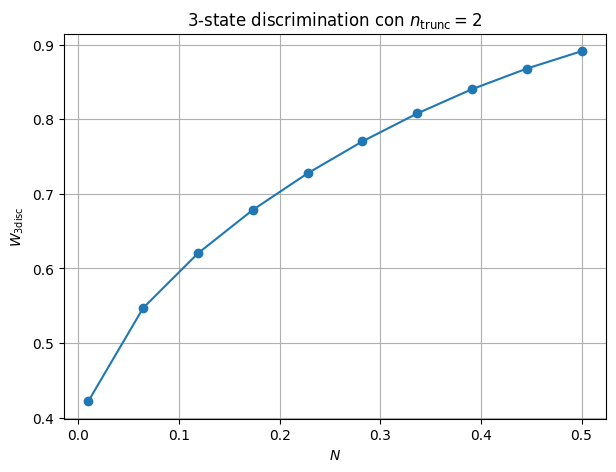

In [ ]:

N_values = np.linspace(0.01, 0.5, 10)
sdp_values = []

for N in N_values:
    omega = poisson_omega(N, n_x=3, n_trunc=2)
    res = solve_n_state_discrimination(
        n_x=3,
        n_trunc=2,
        omega=omega,
        solver="CLARABEL",
        include_extra_words=True,
    )
    sdp_values.append(res["sdp_upper_bound"])

plt.figure(figsize=(7, 5))
plt.plot(N_values, sdp_values, "o-")
plt.xlabel(r"$N$")
plt.ylabel(r"$W_{3\mathrm{disc}}$")
plt.title(r"3-states discrimination with $n_{\mathrm{trunc}}=2$")
plt.grid(True)
plt.show()